# Empirical Motivation

Establishes motivation using empircal data for the decision objective and credit loss distribution.

In [20]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'empirical' / 'results').exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'empirical' / 'notebooks'))
from minou_colours import MINOU_COLOURS

FIGURES_DIR = ROOT / 'decision_problem' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

chargeoff_path = ROOT / 'empirical' / 'data' / 'raw' / 'fred' / 'CORBLACBS.csv'
history = pd.read_csv(chargeoff_path, parse_dates=['DATE']).rename(columns={'CORBLACBS': 'charge_off_rate'}).set_index('DATE').sort_index()


In [21]:
# Use the same continuous oracle solver as the PTO and black-box notebooks.
SIMULATION_ROOT = ROOT / 'simulation'
import sys
if str(SIMULATION_ROOT) not in sys.path:
    sys.path.insert(0, str(SIMULATION_ROOT))
from common import decision as dec
from common.decision import DecisionConfig

LGD, LEVERAGE, Y_BAR, LAMBDA, PD_FLOOR = 0.45, 10.0, 0.0168, 10.0, 3e-4
M, K1, RHO_SCALE = 2.5, 1.0, 0.03
DCFG = DecisionConfig(
    LGD=LGD, K1=K1, ell=LEVERAGE, Y_BAR=Y_BAR, lambda_shortfall=LAMBDA,
    M=M, RHO_SCALE=RHO_SCALE, APPLY_PD_FLOOR=True, PD_FLOOR=PD_FLOOR,
    ALPHA_BOUNDS=(0.0, 1.0), ALPHA_OPT_XATOL=1e-10,
)

def quarterly_pd_to_annual(pd_q):
    return dec.quarterly_pd_to_annual(pd_q, DCFG)

def k_irb_from_annual_pd(pd_a):
    return dec.k_irb_from_annual_pd(pd_a, DCFG)

def oracle_from_chargeoff(c_q):
    pd_q = float(dec.clip_pd_q(c_q / LGD, DCFG))
    pd_a = float(dec.quarterly_pd_to_annual(pd_q, DCFG))
    k = float(dec.k_irb_from_annual_pd(pd_a, DCFG))
    return dec.optimise_alpha_oracle(c_q, k, DCFG)

history['c_q'] = history['charge_off_rate'] / 100.0 / 4.0
history = history.dropna(subset=['c_q']).copy()
history[['alpha_oracle_computed', 'utility_oracle_computed']] = history['c_q'].apply(lambda c: pd.Series(oracle_from_chargeoff(c)))
df = history[['c_q', 'alpha_oracle_computed', 'utility_oracle_computed']].copy()

## Oracle behaviour over time

The full sample is shown in one plot. The alpha axis is deliberately zoomed
to 0.5–0.8 so the allocation swings are visible.

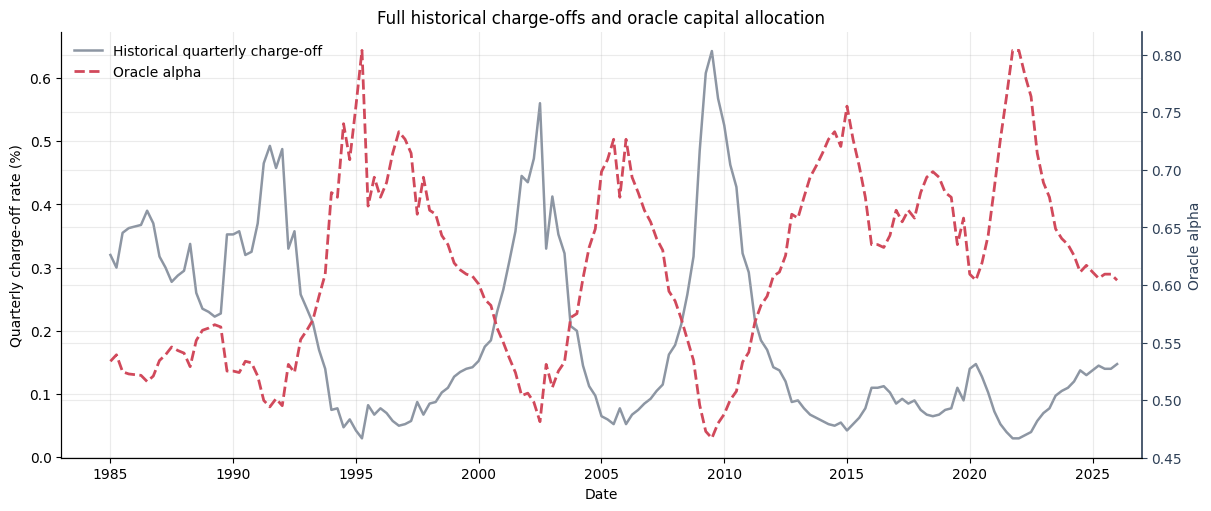

In [22]:
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25})
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax2 = ax.twinx()
ax.plot(df.index, df['c_q'] * 100, color=MINOU_COLOURS['grey'], lw=1.8, label='Historical quarterly charge-off')
ax2.plot(df.index, df['alpha_oracle_computed'], color=MINOU_COLOURS['coral'], lw=2.0, ls='--', label='Oracle alpha')
ax.set_ylabel('Quarterly charge-off rate (%)'); ax2.set_ylabel('Oracle alpha'); ax2.set_ylim(0.45, 0.82)
ax2.set_yticks(np.arange(0.45, 0.821, 0.05)); ax2.yaxis.set_major_formatter(__import__('matplotlib').ticker.FormatStrFormatter('%.2f'))
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(MINOU_COLOURS['navy']); ax2.spines['right'].set_linewidth(1.2)
ax2.tick_params(axis='y', colors=MINOU_COLOURS['navy']); ax2.yaxis.label.set_color(MINOU_COLOURS['navy'])
ax.set_title('Full historical charge-offs and oracle capital allocation')
ax.set_xlabel('Date'); ax.set_xlim(pd.Timestamp('1983-01-01'), pd.Timestamp('2027-01-01')); ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
lines = ax.get_lines() + ax2.get_lines(); ax.legend(lines, [line.get_label() for line in lines], frameon=False, loc='upper left')
fig.savefig(FIGURES_DIR / f'historical_oracle_against_chargeoffs.png', dpi=200, bbox_inches='tight')
plt.show()

## Basel asset correlation and IRB capital requirement

This reproduces the regulatory curves from `IRB_capital_constraint.ipynb`, using
the v2 convention that `K_IRB` receives annualised PD. The two curves share the
same annualised-PD x-axis and use separate y-axes because they have different scales.

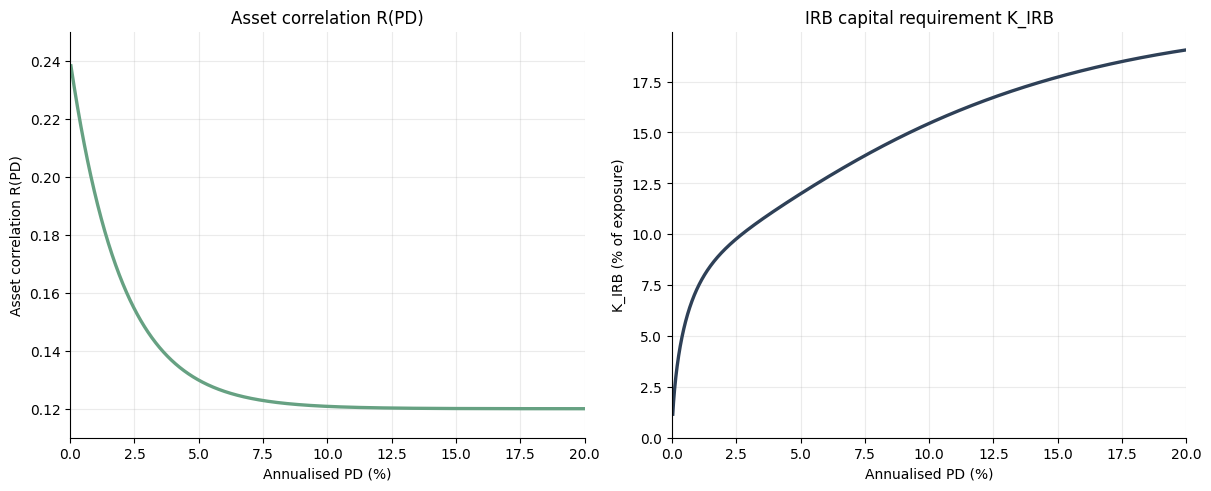

In [23]:
pd_annual_grid = np.linspace(PD_FLOOR, 0.20, 2000)
r_grid = 0.12 * (1 - np.exp(-50 * pd_annual_grid)) / (1 - np.exp(-50)) + 0.24 * (1 - (1 - np.exp(-50 * pd_annual_grid)) / (1 - np.exp(-50)))
k_grid = k_irb_from_annual_pd(pd_annual_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].plot(pd_annual_grid * 100, r_grid, color=MINOU_COLOURS['sage'], lw=2.4)
axes[0].set_xlabel('Annualised PD (%)'); axes[0].set_ylabel('Asset correlation R(PD)')
axes[0].set_title('Asset correlation R(PD)'); axes[0].set_xlim(0, 20); axes[0].set_ylim(0.11, 0.25)
axes[0].grid(True, alpha=0.25)
axes[1].plot(pd_annual_grid * 100, k_grid * 100, color=MINOU_COLOURS['navy'], lw=2.4)
axes[1].set_xlabel('Annualised PD (%)'); axes[1].set_ylabel('K_IRB (% of exposure)')
axes[1].set_title('IRB capital requirement K_IRB'); axes[1].set_xlim(0, 20); axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.25)
fig.savefig(FIGURES_DIR / 'asset_correlation_and_irb_capital.png', dpi=220, bbox_inches='tight')
plt.show()

## Charge-off regimes and oracle allocation

This reproduces the regime diagnostics from `charge_offs_data.ipynb`.
The post-recession extension is configurable as a fraction of each recession's duration.
The time series and regime distributions are stacked into one thesis-oriented figure.


,Normal regime,Stress regime
Parameter,,
"μ (mean charge-off rate, %)",0.14%,0.36%
"σ (standard deviation, %)",0.10%,0.15%
Implied quarterly PD = μ / LGD (%),0.31%,0.79%
Implied annualised PD (%),1.24%,3.13%
"K_IRB (Basel capital requirement, %)",7.96%,10.40%


,Value
Parameter,
LGD,0.4500
M (maturity),2.5000
K1 (initial capital),1.0000
Leverage,10.0000
y_bar,0.0168
Lambda penalty,10.0000
PD floor,0.0003


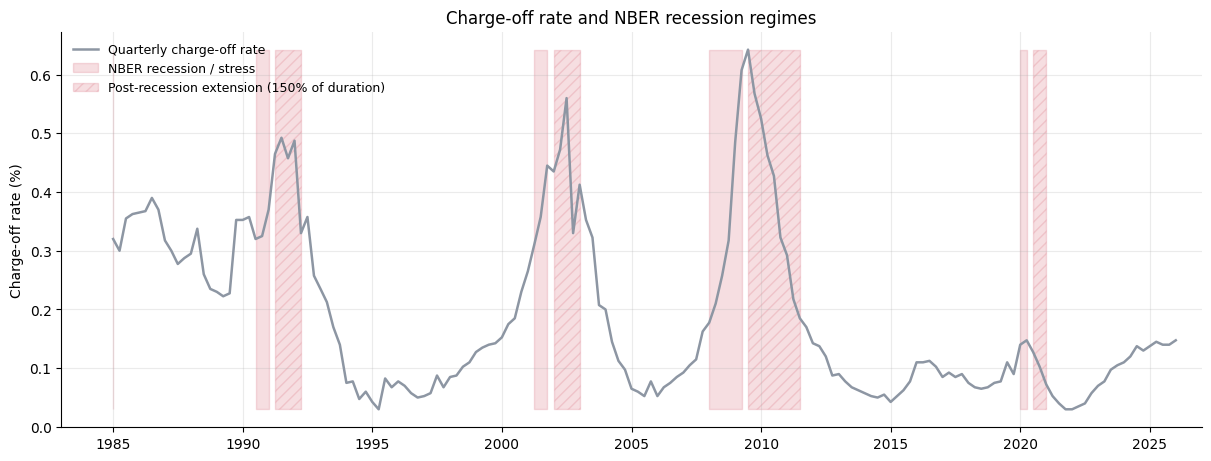

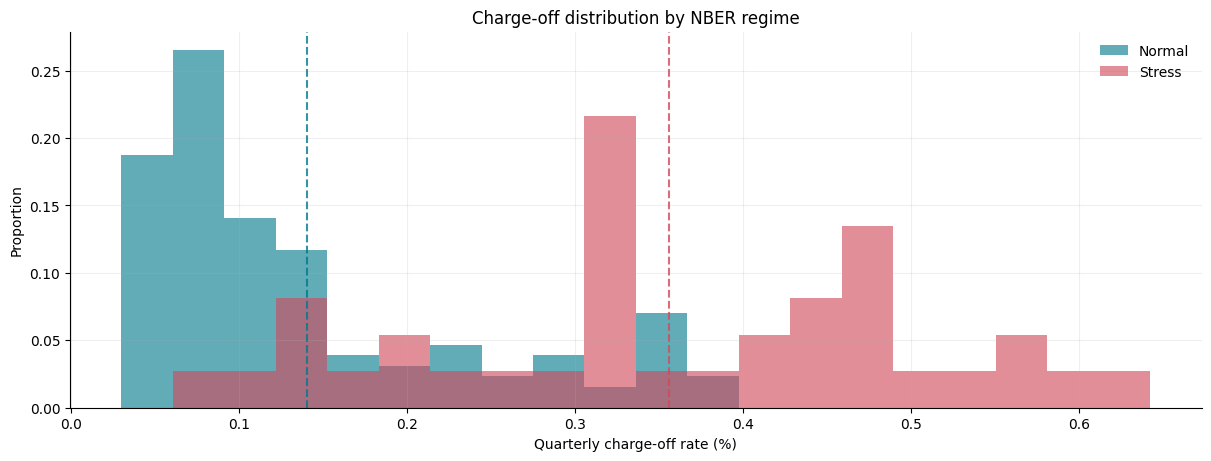

In [27]:
USREC_PATH = ROOT / 'empirical' / 'data' / 'raw' / 'fred'/ 'USREC.csv'
REGIME_EXTENSION_FRACTION = 1.50
usrec = pd.read_csv(USREC_PATH).rename(columns={'observation_date': 'DATE'})
usrec['DATE'] = pd.to_datetime(usrec['DATE'])
usrec['USREC'] = pd.to_numeric(usrec['USREC'].replace('.', np.nan), errors='coerce')
usrec = usrec.dropna(subset=['DATE', 'USREC']).set_index('DATE').sort_index()
usrec_quarterly = usrec['USREC'].astype(int).resample('QS').max().astype(bool)
recession_starts = usrec_quarterly[usrec_quarterly & ~usrec_quarterly.shift(1, fill_value=False)].index
recession_ends = usrec_quarterly[usrec_quarterly & ~usrec_quarterly.shift(-1, fill_value=False)].index
regimes = history[['c_q']].rename(columns={'c_q': 'charge_off_rate'}).copy()
regimes['nber_recession'] = usrec_quarterly.reindex(regimes.index, method='ffill').fillna(False).astype(bool)
regimes['nber_recession_extended'] = regimes['nber_recession'].copy()
for start, end in zip(recession_starts, recession_ends):
    duration_q = max(1, (end.year - start.year) * 4 + end.quarter - start.quarter + 1)
    extension_q = int(np.ceil(duration_q * REGIME_EXTENSION_FRACTION))
    extension_end = end + pd.DateOffset(months=3 * extension_q)
    extension_mask = (regimes.index > end) & (regimes.index <= extension_end)
    regimes.loc[extension_mask, 'nber_recession_extended'] = True
regimes['extension_only'] = regimes['nber_recession_extended'] & ~regimes['nber_recession']
regimes['regime'] = np.where(regimes['nber_recession_extended'], 'stress', 'normal')
regime_params = regimes.groupby('regime')['charge_off_rate'].agg(mu='mean', sigma='std', observations='count').reindex(['normal', 'stress'])
regime_table = regime_params.copy()
regime_table['pd_q_mu'] = regime_table['mu'] / LGD
regime_table['pd_a_mu'] = quarterly_pd_to_annual(regime_table['pd_q_mu'].to_numpy())
regime_table['k_irb_pd_a_mu'] = k_irb_from_annual_pd(regime_table['pd_a_mu'].to_numpy())
regime_table['pd_a_mu_minus_1sd'] = quarterly_pd_to_annual(np.maximum((regime_table['mu'] - regime_table['sigma']) / LGD, 1e-6).to_numpy())
regime_table['pd_a_mu_plus_1sd'] = quarterly_pd_to_annual(((regime_table['mu'] + regime_table['sigma']) / LGD).to_numpy())
regime_table['k_irb_mu_minus_1sd'] = k_irb_from_annual_pd(regime_table['pd_a_mu_minus_1sd'].to_numpy())
regime_table['k_irb_mu_plus_1sd'] = k_irb_from_annual_pd(regime_table['pd_a_mu_plus_1sd'].to_numpy())
clean_table = pd.DataFrame({
    'Parameter': ['μ (mean charge-off rate, %)', 'σ (standard deviation, %)', 'Implied quarterly PD = μ / LGD (%)', 'Implied annualised PD (%)', 'K_IRB (Basel capital requirement, %)'],
    'Normal regime': [regime_params.loc['normal', 'mu'] * 100, regime_params.loc['normal', 'sigma'] * 100, regime_table.loc['normal', 'pd_q_mu'] * 100, regime_table.loc['normal', 'pd_a_mu'] * 100, regime_table.loc['normal', 'k_irb_pd_a_mu'] * 100],
    'Stress regime': [regime_params.loc['stress', 'mu'] * 100, regime_params.loc['stress', 'sigma'] * 100, regime_table.loc['stress', 'pd_q_mu'] * 100, regime_table.loc['stress', 'pd_a_mu'] * 100, regime_table.loc['stress', 'k_irb_pd_a_mu'] * 100],
}).set_index('Parameter')
display(clean_table.style.format('{:.2f}%'))
capital_config = pd.DataFrame({
    'Parameter': ['LGD', 'M (maturity)', 'K1 (initial capital)', 'Leverage', 'y_bar', 'Lambda penalty', 'PD floor'],
    'Value': [LGD, 2.5, 1.0, LEVERAGE, Y_BAR, LAMBDA, PD_FLOOR],
}).set_index('Parameter')
display(capital_config)
chargeoff_pct = regimes['charge_off_rate'] * 100.0

COLOUR_LINE, COLOUR_NORMAL, COLOUR_STRESS = MINOU_COLOURS['grey'], MINOU_COLOURS['teal'], MINOU_COLOURS['coral']
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
ax.plot(regimes.index, chargeoff_pct, color=COLOUR_LINE, lw=1.8, label='Quarterly charge-off rate')
ymin, ymax = chargeoff_pct.min(), chargeoff_pct.max()
ax.fill_between(regimes.index, ymin, ymax, where=regimes['nber_recession'].to_numpy(), color=COLOUR_STRESS, alpha=0.18, step='mid', label='NBER recession / stress')
ax.fill_between(regimes.index, ymin, ymax, where=regimes['extension_only'].to_numpy(), color=COLOUR_STRESS, alpha=0.18, step='mid', hatch='///', label=f'Post-recession extension ({REGIME_EXTENSION_FRACTION:.0%} of duration)')
ax.set_ylabel('Charge-off rate (%)'); ax.set_title('Charge-off rate and NBER recession regimes')
ax.legend(frameon=False, loc='upper left', fontsize=9); ax.grid(True, alpha=0.25)
ax.set_xlim(pd.Timestamp('1983-01-01'), pd.Timestamp('2027-01-01'))
ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.savefig(FIGURES_DIR / f'chargeoff_nber_regimes.png', dpi=220, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
normal = chargeoff_pct.loc[regimes['regime'].eq('normal')]
stress = chargeoff_pct.loc[regimes['regime'].eq('stress')]
bins = np.linspace(chargeoff_pct.min(), chargeoff_pct.max(), 21)
ax.hist(normal, bins=bins, weights=np.ones(len(normal)) / len(normal), alpha=0.62, color=COLOUR_NORMAL, label='Normal')
ax.hist(stress, bins=bins, weights=np.ones(len(stress)) / len(stress), alpha=0.62, color=COLOUR_STRESS, label='Stress')
ax.axvline(regime_params.loc['normal', 'mu'] * 100, color=COLOUR_NORMAL, ls='--', lw=1.5, alpha=0.8)
ax.axvline(regime_params.loc['stress', 'mu'] * 100, color=COLOUR_STRESS, ls='--', lw=1.5, alpha=0.8)
ax.set_xlabel('Quarterly charge-off rate (%)'); ax.set_ylabel('Proportion'); ax.set_title('Charge-off distribution by NBER regime')
ax.legend(frameon=False, loc='upper right'); ax.grid(True, alpha=0.2)
fig.savefig(FIGURES_DIR / f'chargeoff_regime_distribution.png', dpi=220, bbox_inches='tight')
plt.show()

## Over- versus underprediction cost

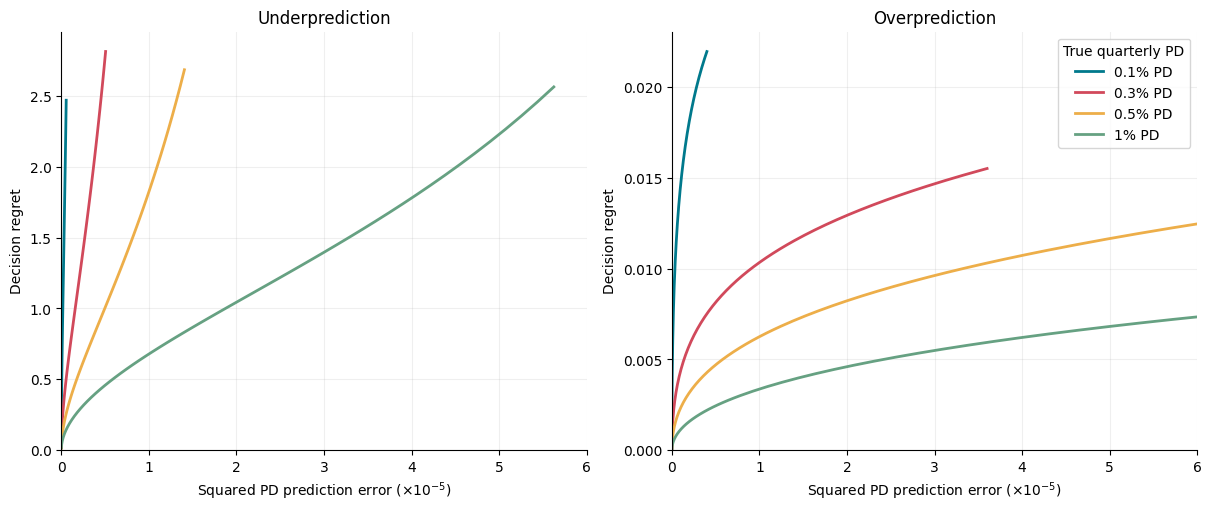

In [28]:
true_pd_levels = [0.001, 0.003, 0.005, 0.010]
forecast_multipliers = np.linspace(0.25, 3.0, 220)

def utility_at_alpha(alpha, c_q, pd_a):
    k = float(k_irb_from_annual_pd(pd_a))
    return float(dec.decision_components(float(alpha), float(c_q), k, DCFG)['utility'])

forecast_diagnostic_rows = []
for pd_true in true_pd_levels:
    c_true = LGD * pd_true
    pd_a_true = float(quarterly_pd_to_annual(pd_true))
    alpha_oracle, utility_oracle = oracle_from_chargeoff(c_true)
    for multiplier in forecast_multipliers:
        pd_forecast = float(np.clip(pd_true * multiplier, 1e-6, 0.99))
        alpha_forecast, _ = oracle_from_chargeoff(LGD * pd_forecast)
        utility_forecast = utility_at_alpha(alpha_forecast, c_true, pd_a_true)
        forecast_diagnostic_rows.append({
            'pd_true_quarterly': pd_true,
            'forecast_multiplier': multiplier,
            'forecast_error': pd_forecast - pd_true,
            'regret': max(utility_oracle - utility_forecast, 0.0),
        })

diagnostic = pd.DataFrame(forecast_diagnostic_rows)
diagnostic['squared_prediction_error_scaled'] = 1e5 * diagnostic['forecast_error'] ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for panel_df, title, ax in [
    (diagnostic[diagnostic['forecast_multiplier'] < 1], 'Underprediction', axes[0]),
    (diagnostic[diagnostic['forecast_multiplier'] > 1], 'Overprediction', axes[1]),
]:
    for pd_true, colour in zip(true_pd_levels, [MINOU_COLOURS['teal'], MINOU_COLOURS['coral'], MINOU_COLOURS['gold'], MINOU_COLOURS['sage']]):
        subset = panel_df[panel_df['pd_true_quarterly'] == pd_true].sort_values('squared_prediction_error_scaled')
        ax.plot(subset['squared_prediction_error_scaled'], subset['regret'], lw=2, color=colour, label=f'{100 * pd_true:.2g}% PD')
    ax.set_title(title)
    ax.set_xlabel(r'Squared PD prediction error ($\times 10^{-5}$)')
    ax.set_ylabel('Decision regret')
    ax.set_xlim(0, 6)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)
axes[1].legend(title='True quarterly PD')
fig.savefig(FIGURES_DIR / 'over_under_prediction_cost.png', dpi=220, bbox_inches='tight')
plt.show()